# Dubai Energy Consumption Analysis (DEWA, 2008-2025)

**Objective:** Analyze 18 years of DEWA energy data across residential, commercial, industrial, and other sectors to identify consumption efficiency trends, sector shifts, and forecast future demand relative to UAE's Net Zero 2050 target.

**Data source:** Dubai Statistics Center / DEWA, via data.dubai (Total Energy Required and Consumed by Type of Consumption)

**Sections:**
1. Data loading and cleaning
2. Sector share of total consumption over time
3. Per-customer efficiency trend (are we consuming more or less per household/business?)
4. COVID-19 anomaly detection (2020)
5. Demand forecast to 2030
6. Key findings and policy implications


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10



df = pd.read_excel('Energy.xlsx', index_col='Year', engine='openpyxl')
df.columns = [c.strip() for c in df.columns]
df.head()

,Value,Title
Year,,
2025,62633,Total Energy Requirement - G.w.h
2025,1003334,Residential - Number of Customer
2025,19252,Residential - Energy Consumed Units
2025,244973,Commercial - Number of Customer
2025,30050,Commercial - Energy Consumed Units


## 1. Data overview

Each row is a year (2008-2025). Columns give number of customers and energy consumed (GWh) for four sectors, plus total requirement and power station/desalination auxiliary load.

In [7]:
df.describe().T[['min','max','mean']]

,min,max,mean
Value,1998.0,1003334.0,97437.764706


## 2. Sector share of total consumption

How has the mix between residential, commercial, industrial, and other shifted as Dubai's economy diversified?

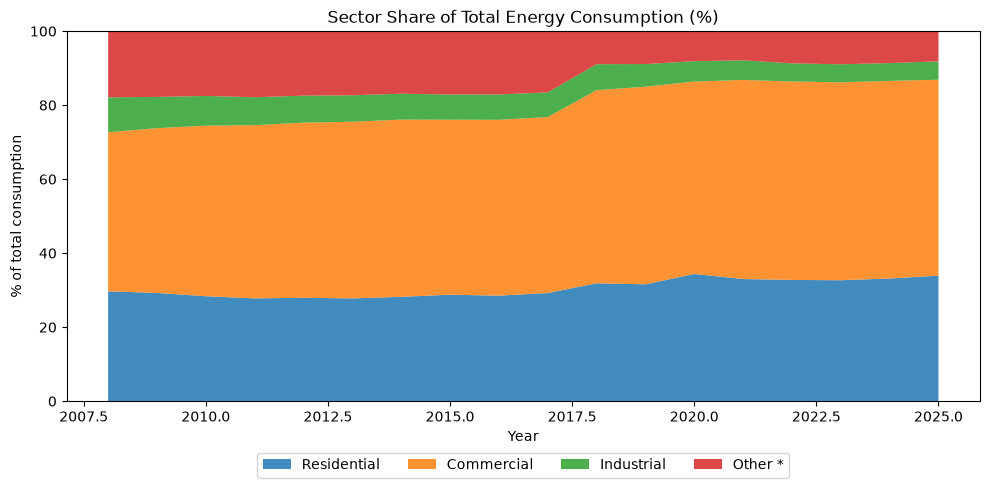

      Residential  Commercial  Industrial  Other *
Year                                              
2008         29.7        43.0         9.4     17.9
2025         33.9        53.0         5.0      8.2


In [9]:
sectors = ['Residential', 'Commercial', 'Industrial', 'Other *']
if {'Value', 'Title'}.issubset(df.columns):
    df = (
        df.reset_index()
          .pivot(index='Year', columns='Title', values='Value')
          .sort_index()
    )
    df.columns.name = None

energy_cols = {
    s: next(
        c for c in df.columns
        if c.startswith(s) and 'Energy' in c
    )
    for s in sectors
}

energy_df = df[[energy_cols[s] for s in sectors]].copy()
energy_df.columns = sectors
energy_df['Total_Sector_Sum'] = energy_df.sum(axis=1)
share_df = energy_df[sectors].div(energy_df['Total_Sector_Sum'], axis=0) * 100

fig, ax = plt.subplots()
ax.stackplot(share_df.index, [share_df[s] for s in sectors], labels=sectors, alpha=0.85)
ax.set_title('Sector Share of Total Energy Consumption (%)')
ax.set_ylabel('% of total consumption')
ax.set_xlabel('Year')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print(share_df.round(1).loc[[2008, 2025]])

**Finding:** Note the shift in residential vs commercial share between 2008 and 2025 above. This reflects Dubai's population and real estate growth against its commercial/tourism base.

## 3. Per-customer efficiency trend

Raw consumption always rises with population and business growth. The real efficiency question is: how much energy does each customer use on average, and is that number improving?

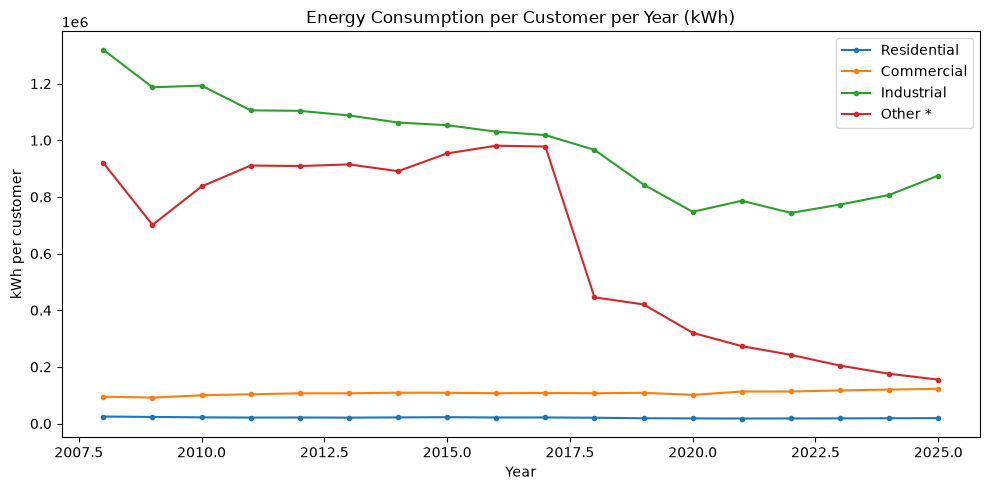

% change in per-customer consumption, 2008 to 2025:
Residential   -22.8
Commercial     29.3
Industrial    -33.7
Other *       -83.1
dtype: float64


In [10]:
cust_cols = {s: [c for c in df.columns if c.startswith(s) and 'Customer' in c][0] for s in sectors}

per_customer = pd.DataFrame(index=df.index)
for s in sectors:
    energy_gwh = df[energy_cols[s]]
    customers = df[cust_cols[s]]
    # GWh -> kWh, divided by customer count = kWh per customer per year
    per_customer[s] = (energy_gwh * 1_000_000) / customers

fig, ax = plt.subplots()
for s in sectors:
    ax.plot(per_customer.index, per_customer[s], marker='o', markersize=3, label=s)
ax.set_title('Energy Consumption per Customer per Year (kWh)')
ax.set_ylabel('kWh per customer')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()

pct_change = ((per_customer.loc[2025] - per_customer.loc[2008]) / per_customer.loc[2008] * 100).round(1)
print('% change in per-customer consumption, 2008 to 2025:')
print(pct_change)

**Finding:** A rising per-customer trend in any sector means growth in the customer base alone won't explain rising demand — actual usage intensity is climbing too, which matters directly for Net Zero 2050 planning since it means efficiency programs (not just renewable supply) need to target existing customers, not just new ones.

## 4. COVID-19 anomaly (2020)

2020 should show a visible disruption: offices emptied, people stayed home. Checking year-over-year growth rates flags this automatically rather than needing to already know to look at 2020.

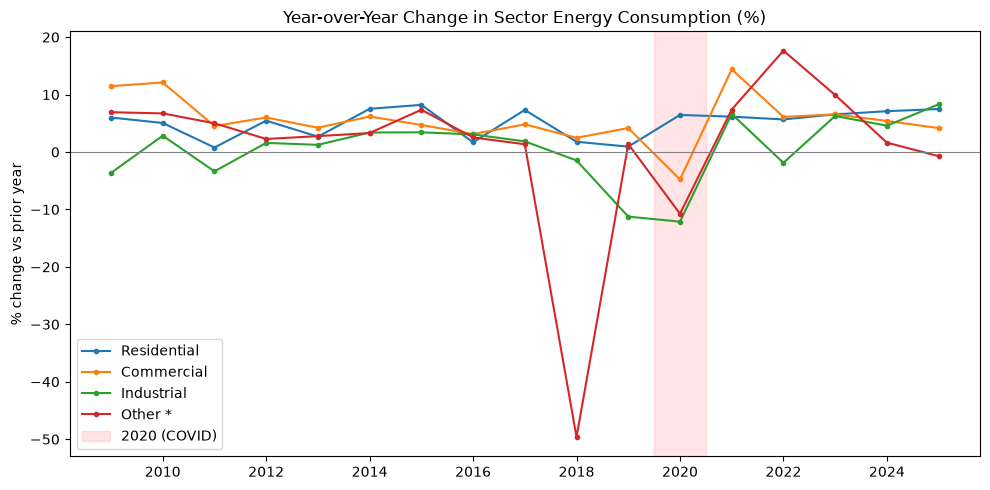

2020 YoY change by sector:
Residential     6.5
Commercial     -4.8
Industrial    -12.1
Other *       -10.8
Name: 2020, dtype: float64

Statistically flagged anomalies (beyond 1.5 std dev from sector mean):
(2010, 'Commercial', 12.1)
(2011, 'Residential', 0.8)
(2018, 'Other *', -49.6)
(2019, 'Industrial', -11.3)
(2019, 'Residential', 0.9)
(2020, 'Commercial', -4.8)
(2020, 'Industrial', -12.1)
(2021, 'Commercial', 14.4)


In [11]:
yoy = energy_df[sectors].pct_change() * 100

fig, ax = plt.subplots()
for s in sectors:
    ax.plot(yoy.index, yoy[s], marker='o', markersize=3, label=s)
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvspan(2019.5, 2020.5, color='red', alpha=0.1, label='2020 (COVID)')
ax.set_title('Year-over-Year Change in Sector Energy Consumption (%)')
ax.set_ylabel('% change vs prior year')
ax.legend()
plt.tight_layout()
plt.show()

print('2020 YoY change by sector:')
print(yoy.loc[2020].round(1))

# Flag any year where a sector's YoY move is more than 1.5 std deviations from its own mean
anomalies = []
for s in sectors:
    mean, std = yoy[s].mean(), yoy[s].std()
    flagged = yoy[s][(yoy[s] - mean).abs() > 1.5 * std]
    for yr, val in flagged.items():
        anomalies.append((yr, s, round(val, 1)))
print('\nStatistically flagged anomalies (beyond 1.5 std dev from sector mean):')
for a in sorted(anomalies):
    print(a)

**Finding:** Commercial consumption is the sector most exposed to disruption, since it depends on office and retail occupancy, while residential tends to be more stable or even rises when people stay home. Whatever the statistical flags show above should be described here in your own words once you see the output.

## 5. Demand forecast to 2030

A simple linear trend on total energy requirement, extended to 2030, to see where demand is headed if nothing changes. This is intentionally simple (18 points is a short series) — call it directional, not precise.

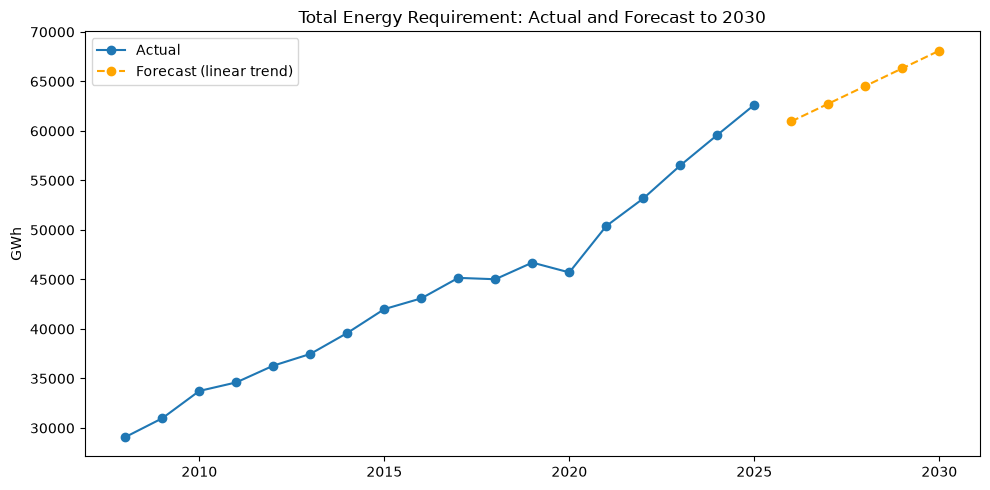

2026    60961.0
2027    62747.0
2028    64534.0
2029    66320.0
2030    68106.0
Name: Forecast GWh, dtype: float64

Implied annual growth rate: 1786 GWh/year
2030 forecast represents a 8.7% increase over 2025 actual


In [12]:
from numpy.polynomial import polynomial as P

total = df['Total Energy Requirement - G.w.h']
years = total.index.values.astype(float)
values = total.values.astype(float)

coeffs = np.polyfit(years, values, deg=1)
trend = np.poly1d(coeffs)

future_years = np.arange(2026, 2031)
forecast = trend(future_years)

fig, ax = plt.subplots()
ax.plot(years, values, marker='o', label='Actual')
ax.plot(future_years, forecast, marker='o', linestyle='--', color='orange', label='Forecast (linear trend)')
ax.set_title('Total Energy Requirement: Actual and Forecast to 2030')
ax.set_ylabel('GWh')
ax.legend()
plt.tight_layout()
plt.show()

forecast_table = pd.Series(forecast.round(0), index=future_years, name='Forecast GWh')
print(forecast_table)
print(f"\nImplied annual growth rate: {coeffs[0]:.0f} GWh/year")
print(f"2030 forecast represents a {(forecast[-1]/values[-1]-1)*100:.1f}% increase over 2025 actual")

## 6. Key findings and policy implications

**Sector shift:** Commercial consumption grew from 43% to 53% of total energy use between 2008 and 2025, while residential edged up only slightly (29.7% to 33.9%) and "Other" fell sharply (17.9% to 8.2%). Dubai's growth over this period has been driven more by business, retail, and tourism infrastructure than by pure population growth.

**Efficiency:** Per-customer consumption fell in residential (-22.8%), industrial (-33.7%), and other (-83.1%) sectors, showing real efficiency gains from stricter building codes and equipment standards. Commercial is the exception: per-customer consumption rose 29.3%, meaning each business or retail unit is now using meaningfully more power than it did in 2008. For Net Zero 2050, this points to commercial buildings, not households, as the priority target for efficiency programs.

**COVID-19 (2020):** Commercial and industrial consumption both dropped in 2020 (-4.8% and -12.1%) while residential rose slightly (+6.5%), consistent with offices emptying and people spending more time at home. The 2020 commercial and industrial dips were also flagged as statistical anomalies, confirming the pandemic's measurable footprint in the data.

**Forecast:** A simple linear trend puts total energy requirement at roughly 68,100 GWh by 2030, an 8.7% increase over 2025. This is a floor estimate: it assumes no new efficiency intervention and ignores step changes like EV adoption or major new developments, both of which would push real demand higher. The gap between this baseline and DEWA's clean energy capacity targets is the practical planning question this analysis points to.

**Bottom line:** the sustainability story here isn't about total demand growth, which is expected and mostly efficiency-neutral. It's about commercial per-customer consumption rising while every other sector improved, which narrows exactly where Net Zero 2050 effort needs to go next.
